# Train Action-Chunking-Transformer (ACT) on your Dataset
Train the ACT model on your custom dataset. In this example, we set chunk_size as 10. 

In [2]:
import torch
import sys
sys.path.append('/home/student/Desktop/lerobot-papras')
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.dataset_tools import merge_datasets, split_dataset
from lerobot.datasets.utils import dataset_to_policy_features
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.configs.types import FeatureType
from lerobot.datasets.factory import resolve_delta_timestamps
from torch.utils.data import ConcatDataset

In [30]:
device = torch.device("cuda")

# Number of offline training steps (we'll only do offline training for this example.)
# Adjust as you prefer. 5000 steps are needed to get something worth evaluating.
training_steps = 5000
log_freq = 100
n_action_steps = 10
chunk_size = 10 
batch_size = 64
num_workers = 4

## Dataset Construction

In [5]:
# create a merged dataset for train/val split 
test_dataset = LeRobotDataset("nov_19e_20", root='./nov_19_e20') #20 episodes
train_dataset_1 = LeRobotDataset("dec_8_e60_v1", root='./dec_8_e60_v1') #20 episodes
train_dataset_2 = LeRobotDataset("dec_8_e60_v2", root='./dec_8_e60_v2') #20 episodes
train_dataset_3 = LeRobotDataset("dec_8_e60_v3", root='./dec_8_e60_v3') #20 episodes

In [ ]:
# Create dataets of size 20, 40, 60 and save
train_val_60 = merge_datasets([train_dataset_1, train_dataset_2, train_dataset_3], "dec_8_all", "./dec_8_all")
train_val_40 = merge_datasets([train_dataset_1, train_dataset_2], "dec_8_40", "./dec_8_40")
train_val_20 = merge_datasets([train_dataset_1], "dec_8_20", "./dec_8_20")


Copy data and videos:   0%|          | 0/3 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Copy data and videos: 100%|██████████| 1/1 [00:04<00:00,  4.64s/it]


## Policy Configuration and Initialize


In [10]:
# When starting from scratch (i.e. not from a pretrained policy), we need to specify 2 things before
# creating the policy:
#   - input/output shapes: to properly size the policy
#   - dataset stats: for normalization and denormalization of input/outputs

# Load metadata for each of our datasets 
dataset_60_metadata = LeRobotDatasetMetadata("dec_8_all", root='./dec_8_all')
dataset_40_metadata = LeRobotDatasetMetadata("dec_8_40", root='./dec_8_40')
dataset_20_metadata = LeRobotDatasetMetadata("dec_8_20", root='./dec_8_20')

assert(dataset_60_metadata.features==dataset_40_metadata.features)
assert(dataset_60_metadata.features==test_dataset.meta.features)
assert(dataset_60_metadata.features==dataset_20_metadata.features)

features = dataset_to_policy_features(test_dataset.features)
output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
input_features = {key: ft for key, ft in features.items() if key not in output_features}
# input_features.pop("observation.wrist_image")

# Policies are initialized with a configuration class, in this case `DiffusionConfig`. For this example,
# we'll just use the defaults and so no arguments other than input/output features need to be passed.
cfg = ACTConfig(input_features=input_features, output_features=output_features, chunk_size=chunk_size, n_action_steps=n_action_steps)

# This allows us to construct the data with action chunking
delta_timestamps = resolve_delta_timestamps(cfg, dataset_60_metadata)


## Load Datasets

In [4]:
from torchvision import transforms

class AddGaussianNoise(object):
    """
    Adds Gaussian noise to a tensor.
    """
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Adds noise: tensor remains a tensor.
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

# Create a transformation pipeline that converts a PIL image to a tensor, then adds noise.
transform = transforms.Compose([
    AddGaussianNoise(mean=0., std=0.02),
    transforms.Lambda(lambda x: x.clamp(0, 1))
])


In [31]:
# We can then instantiate the dataset with these delta_timestamps configuration.
dataset_20 = LeRobotDataset("dec_8_20", delta_timestamps=delta_timestamps, root='./dec_8_20', image_transforms=transform)
dataset_40 = LeRobotDataset("dec_8_40", delta_timestamps=delta_timestamps, root='./dec_8_40', image_transforms=transform)
dataset_60 = LeRobotDataset("dec_8_all", delta_timestamps=delta_timestamps, root='./dec_8_all', image_transforms=transform)
dataset_test = LeRobotDataset("nov_19e_20", delta_timestamps=delta_timestamps, root='./nov_19_e20', image_transforms=transform)

# Then we create our optimizer and dataloader for offline training.

dataloader_20 = torch.utils.data.DataLoader(
    dataset_20,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_40 = torch.utils.data.DataLoader(
    dataset_40,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_60 = torch.utils.data.DataLoader(
    dataset_60,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

print(len(dataloader_20), len(dataloader_40), len(dataloader_60))

80 171 256


In [27]:
class EpisodeSampler(torch.utils.data.Sampler):
    """
    Sampler for a single episode
    """
    def __init__(self, dataset: LeRobotDataset, episode_index: int):
        episode = dataset.meta.episodes.filter(lambda example: example["episode_index"]==episode_index)[0]
        from_idx = episode["dataset_from_index"],
        to_idx = episode["dataset_to_index"]
        # print(from_idx, to_idx)
        self.frame_ids = range(from_idx[0], to_idx)

    def __iter__(self):
        return iter(self.frame_ids)

    def __len__(self) -> int:
        return len(self.frame_ids)
        

## 20 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [ ]:
lr = 1e-4

In [34]:
# We can now instantiate our policy with this config and the dataset stats.
policy_20 = ACTPolicy(cfg)
policy_20.train()
policy_20.to(device)

optimizer = torch.optim.Adam(policy_20.parameters(), lr=lr)

In [35]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_20:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_20.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 84.492
step: 100 loss: 2.552
step: 200 loss: 1.719
step: 300 loss: 1.331
step: 400 loss: 0.996
step: 500 loss: 0.715
step: 600 loss: 0.560
step: 700 loss: 0.434
step: 800 loss: 0.364
step: 900 loss: 0.317
step: 1000 loss: 0.273
step: 1100 loss: 0.226
step: 1200 loss: 0.204
step: 1300 loss: 0.201
step: 1400 loss: 0.172
step: 1500 loss: 0.167
step: 1600 loss: 0.153
step: 1700 loss: 0.143
step: 1800 loss: 0.135
step: 1900 loss: 0.117
step: 2000 loss: 0.121
step: 2100 loss: 0.117
step: 2200 loss: 0.120
step: 2300 loss: 0.099
step: 2400 loss: 0.098
step: 2500 loss: 0.093
step: 2600 loss: 0.087
step: 2700 loss: 0.087
step: 2800 loss: 0.082
step: 2900 loss: 0.083
step: 3000 loss: 0.076
step: 3100 loss: 0.074
step: 3200 loss: 0.068
step: 3300 loss: 0.066
step: 3400 loss: 0.062
step: 3500 loss: 0.059
step: 3600 loss: 0.061
step: 3700 loss: 0.058
step: 3800 loss: 0.054
step: 3900 loss: 0.052
step: 4000 loss: 0.053
step: 4100 loss: 0.054
step: 4200 loss: 0.051
step: 4300 loss: 0.047

In [36]:
# Save the policy to disk.
policy_20.save_pretrained('./ckpt/act_20')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [37]:
policy_20.eval()
actions = []
gt_actions = []
images = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_20.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_20.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.176


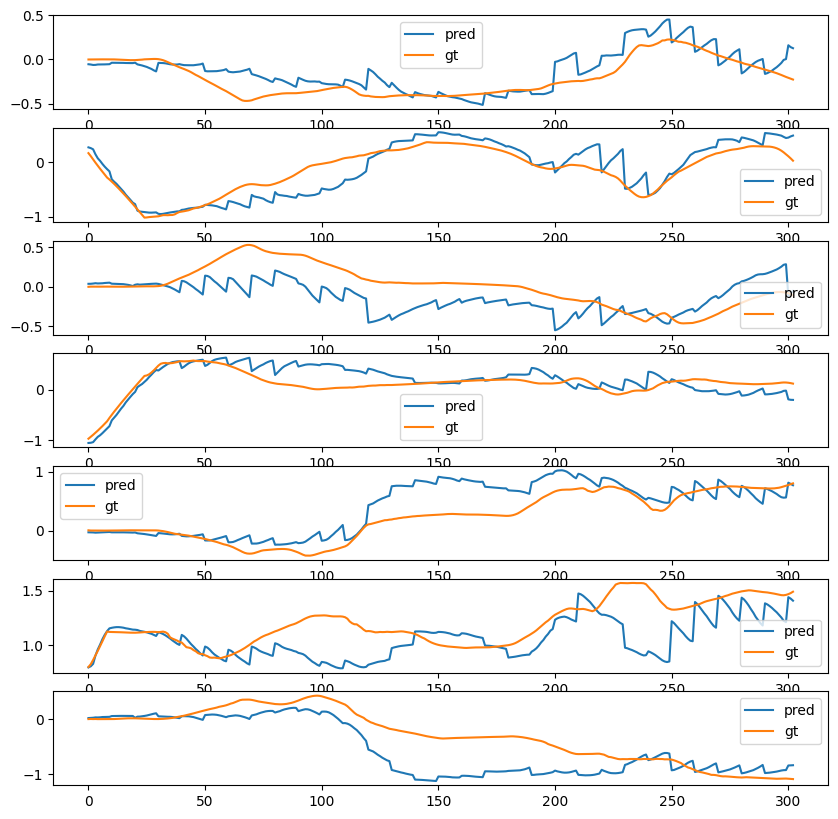

In [38]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()

## 40 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [ ]:
# We can now instantiate our policy with this config and the dataset stats.
policy_40 = ACTPolicy(cfg)
policy_40.train()
policy_40.to(device)

optimizer = torch.optim.Adam(policy_40.parameters(), lr=lr)

In [ ]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_40:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_40.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 84.492
step: 100 loss: 2.552
step: 200 loss: 1.719
step: 300 loss: 1.331
step: 400 loss: 0.996
step: 500 loss: 0.715
step: 600 loss: 0.560
step: 700 loss: 0.434
step: 800 loss: 0.364
step: 900 loss: 0.317
step: 1000 loss: 0.273
step: 1100 loss: 0.226
step: 1200 loss: 0.204
step: 1300 loss: 0.201
step: 1400 loss: 0.172
step: 1500 loss: 0.167
step: 1600 loss: 0.153
step: 1700 loss: 0.143
step: 1800 loss: 0.135
step: 1900 loss: 0.117
step: 2000 loss: 0.121
step: 2100 loss: 0.117
step: 2200 loss: 0.120
step: 2300 loss: 0.099
step: 2400 loss: 0.098
step: 2500 loss: 0.093
step: 2600 loss: 0.087
step: 2700 loss: 0.087
step: 2800 loss: 0.082
step: 2900 loss: 0.083
step: 3000 loss: 0.076
step: 3100 loss: 0.074
step: 3200 loss: 0.068
step: 3300 loss: 0.066
step: 3400 loss: 0.062
step: 3500 loss: 0.059
step: 3600 loss: 0.061
step: 3700 loss: 0.058
step: 3800 loss: 0.054
step: 3900 loss: 0.052
step: 4000 loss: 0.053
step: 4100 loss: 0.054
step: 4200 loss: 0.051
step: 4300 loss: 0.047

In [ ]:
# Save the policy to disk.
policy_40.save_pretrained('./ckpt/act_40')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [ ]:
policy_40.eval()
actions = []
gt_actions = []
images = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_40.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_40.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.222


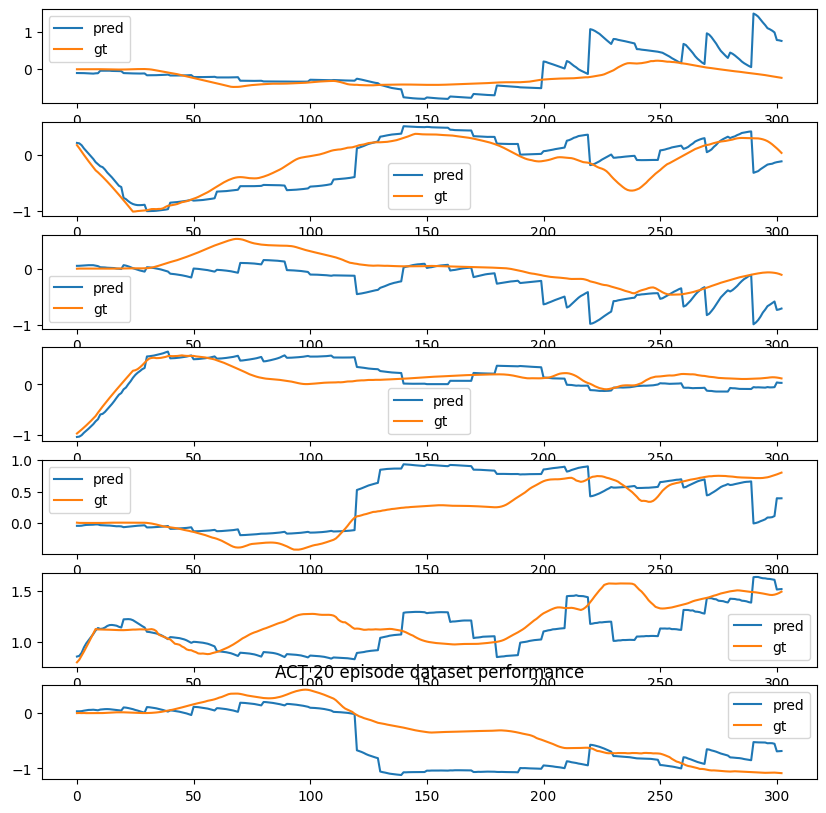

In [ ]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()

## 60 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [ ]:
# We can now instantiate our policy with this config and the dataset stats.
policy_60 = ACTPolicy(cfg)
policy_60.train()
policy_60.to(device)

optimizer = torch.optim.Adam(policy_60.parameters(), lr=lr)

In [ ]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_60:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_60.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 84.492
step: 100 loss: 2.552
step: 200 loss: 1.719
step: 300 loss: 1.331
step: 400 loss: 0.996
step: 500 loss: 0.715
step: 600 loss: 0.560
step: 700 loss: 0.434
step: 800 loss: 0.364
step: 900 loss: 0.317
step: 1000 loss: 0.273
step: 1100 loss: 0.226
step: 1200 loss: 0.204
step: 1300 loss: 0.201
step: 1400 loss: 0.172
step: 1500 loss: 0.167
step: 1600 loss: 0.153
step: 1700 loss: 0.143
step: 1800 loss: 0.135
step: 1900 loss: 0.117
step: 2000 loss: 0.121
step: 2100 loss: 0.117
step: 2200 loss: 0.120
step: 2300 loss: 0.099
step: 2400 loss: 0.098
step: 2500 loss: 0.093
step: 2600 loss: 0.087
step: 2700 loss: 0.087
step: 2800 loss: 0.082
step: 2900 loss: 0.083
step: 3000 loss: 0.076
step: 3100 loss: 0.074
step: 3200 loss: 0.068
step: 3300 loss: 0.066
step: 3400 loss: 0.062
step: 3500 loss: 0.059
step: 3600 loss: 0.061
step: 3700 loss: 0.058
step: 3800 loss: 0.054
step: 3900 loss: 0.052
step: 4000 loss: 0.053
step: 4100 loss: 0.054
step: 4200 loss: 0.051
step: 4300 loss: 0.047

In [ ]:
# Save the policy to disk.
policy_20.save_pretrained('./ckpt/act_60')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [ ]:
policy_60.eval()
actions = []
gt_actions = []
images = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_60.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_60.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.222


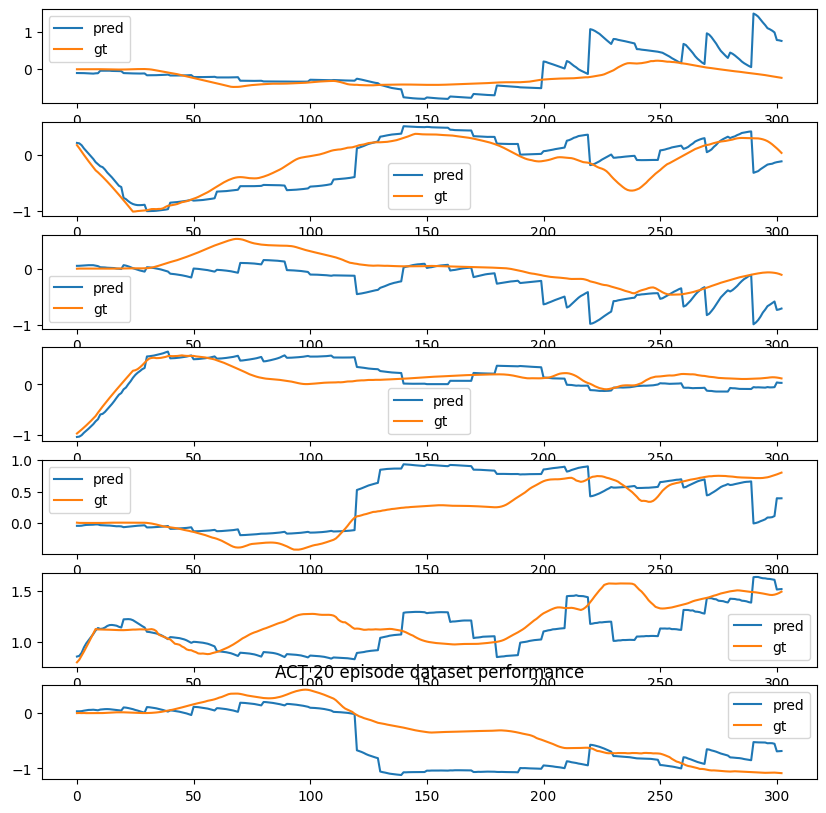

In [ ]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()